# Phase 2 — Getting the data ready

A model is only as good as the data you feed it, and *how* you feed it. This notebook is about everything that happens **before** training:

1. Download the real hotdog / not-hotdog dataset.
2. Look at it — images and class balance.
3. Split it into **train / validation / test** and understand *why*.
4. Build a PyTorch `Dataset` and `DataLoader` with **transforms** (resize, normalize) and **augmentation**.

No neural network yet. By the end you'll have batches of tensors ready to train on in Phase 3.

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from datasets import load_dataset

torch.manual_seed(42)  # reproducibility: same 'random' choices every run

/Users/mack/miniconda3/envs/nothotdog/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Download the dataset

Two lines, no account needed. The first run downloads and caches it; later runs are instant.

In [2]:
raw = load_dataset("truepositive/hotdog_nothotdog")
print(raw)

# The label names. Note the order: index 0 = 'hotdog', index 1 = 'not_hotdog'.
CLASSES = raw["train"].features["label"].names
print("\nClasses:", CLASSES)

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 200
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 50
    })
})

Classes: ['hotdog', 'not_hotdog']


## 2. Look at the data

**Always look at your data before training.** You catch mislabeled images, weird sizes, and surprises here — not after wasting an hour training on garbage.

How many of each class in train: Counter({0: 100, 1: 100})


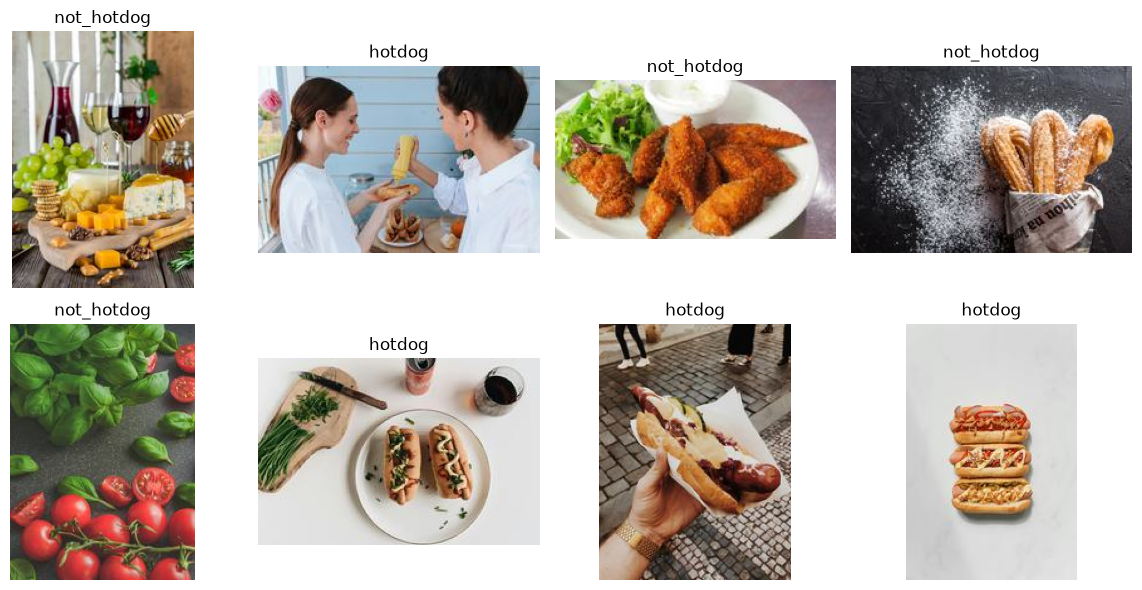

In [3]:
from collections import Counter
print("How many of each class in train:", Counter(raw["train"]["label"]))
# Balanced classes (equal hotdog / not_hotdog) matter: if 95% were 'not_hotdog',
# a lazy model could score 95% by always guessing 'not_hotdog' and learn nothing.

# Show 8 random images with their labels.
import random
idxs = random.sample(range(len(raw["train"])), 8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes.flat, idxs):
    ex = raw["train"][i]
    ax.imshow(ex["image"])
    ax.set_title(CLASSES[ex["label"]])
    ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Train / validation / test split

Three buckets, three different jobs:

- **Train** — the model learns from these.
- **Validation** — the model *never learns* from these; we peek at them during training to see if it's actually getting better or just memorizing. This is how we catch **overfitting**.
- **Test** — touched **once**, at the very end, for an honest final grade. If you tune your model against the test set, you've secretly cheated and your reported accuracy is a lie.

This dataset ships with `train` (200) and `validation` (50). We'll treat the provided 50 as our **untouchable test set**, and carve the 200 into our own train (160) + validation (40).

In [4]:
test_hf = raw["validation"]   # 50 images — we pretend these don't exist until Phase 5
full_hf = raw["train"]        # 200 images — we split these into train + val

# Shuffle the 200 indices with a fixed seed, then slice off 40 for validation.
n = len(full_hf)
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n, generator=g).tolist()
val_idx, train_idx = perm[:40], perm[40:]
print(f"train: {len(train_idx)}  |  val: {len(val_idx)}  |  test: {len(test_hf)}")

train: 160  |  val: 40  |  test: 50


## 4. Transforms: turning a PIL image into a model-ready tensor

Neural networks need tensors of a fixed size and a consistent scale. A transform is a pipeline that does this. Two key ideas:

**Normalization** — we scale pixel values using the mean/std of ImageNet (the giant dataset the Phase 4 pretrained model was trained on). Using the same numbers now means our data will already be in the right range when we get there.

**Augmentation** (train only) — we randomly flip/crop the *training* images each epoch so the model sees slightly different versions and can't just memorize exact pixels. It's free extra data. We do **not** augment val/test — we want to measure those on clean, consistent images.

In [5]:
# ImageNet normalization constants (standard, you'll see these everywhere).
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# TRAINING transform: includes random augmentation.
train_tf = T.Compose([
    T.RandomResizedCrop(224),       # random zoom/crop to 224x224
    T.RandomHorizontalFlip(),       # a flipped hotdog is still a hotdog
    T.ToTensor(),                   # PIL image -> tensor, scales 0-255 to 0.0-1.0
    T.Normalize(MEAN, STD),         # center the values using ImageNet stats
])

# EVAL transform (val + test): deterministic, no randomness.
eval_tf = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

## 5. A `Dataset` and a `DataLoader`

- A **`Dataset`** answers two questions: "how many examples?" (`__len__`) and "give me example #i" (`__getitem__`). Our job in `__getitem__` is to take one raw image, run it through the transform, and return `(image_tensor, label)`.
- A **`DataLoader`** wraps a `Dataset` and hands us **batches** (e.g. 32 images at once), optionally shuffled. Training on batches is faster and more stable than one image at a time.

In [6]:
class HotdogDataset(Dataset):
    """Wraps a Hugging Face split + a transform, optionally over a subset of indices."""

    def __init__(self, hf_split, transform, indices=None):
        self.hf = hf_split
        self.transform = transform
        # If no indices given, use the whole split.
        self.indices = indices if indices is not None else list(range(len(hf_split)))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        ex = self.hf[self.indices[i]]
        image = ex["image"].convert("RGB")   # guard against grayscale images
        return self.transform(image), ex["label"]


train_ds = HotdogDataset(full_hf, train_tf, train_idx)
val_ds   = HotdogDataset(full_hf, eval_tf, val_idx)
test_ds  = HotdogDataset(test_hf, eval_tf)

# num_workers=0 keeps things simple inside a notebook on macOS.
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

# Grab one batch to confirm shapes.
images, labels = next(iter(train_loader))
print("One batch of images:", tuple(images.shape), "  <- [batch, channels, height, width]")
print("One batch of labels:", tuple(labels.shape))

One batch of images: (32, 3, 224, 224)   <- [batch, channels, height, width]
One batch of labels: (32,)


## 6. See what the model will actually see

The images are normalized now, so plotting them raw looks weird (values go negative). We **un-normalize** for display only. Re-run this cell a few times — because of augmentation, the same images come back cropped and flipped differently each time. That randomness is the point.

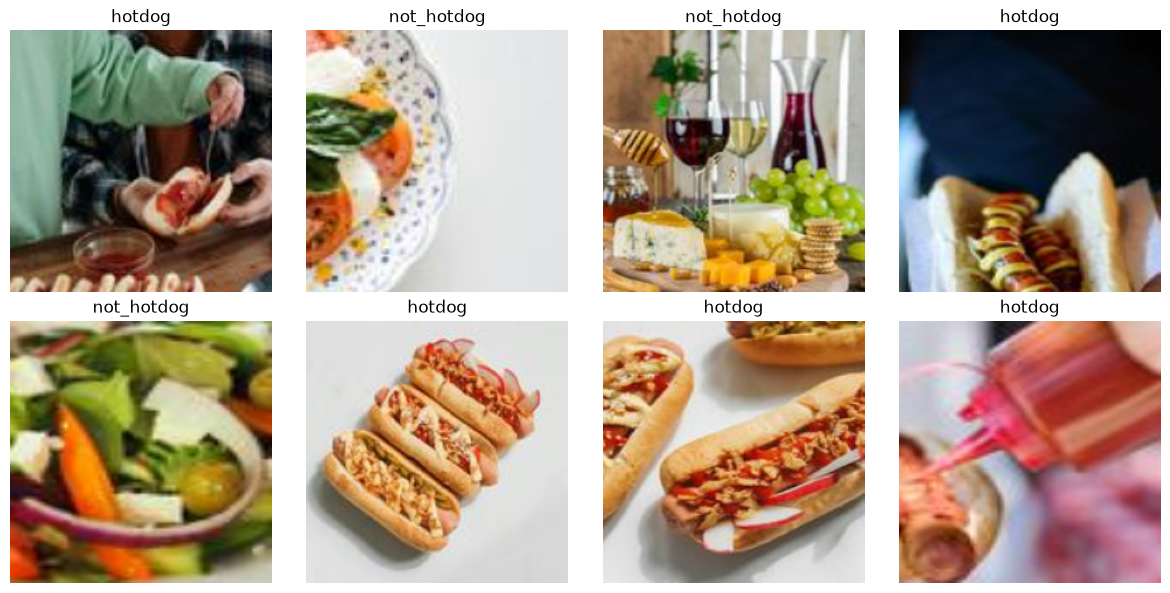

In [7]:
def denormalize(t):
    """Undo Normalize so we can look at the image with human eyes."""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lab in zip(axes.flat, images, labels):
    ax.imshow(denormalize(img))
    ax.set_title(CLASSES[lab])
    ax.axis("off")
plt.tight_layout(); plt.show()

## Recap & what's next

You now have three `DataLoader`s that yield batches of normalized `[32, 3, 224, 224]` tensors with labels. That's the standard input shape for an image model.

Key ideas to hold onto:
- **train / val / test** do three different jobs; never let the model learn from val or test.
- **transforms** make images uniform and correctly scaled.
- **augmentation** is applied to training only, and fights memorization.

In **Phase 3** we'll build a small CNN by hand, write the training loop, feed it `train_loader`, and watch `val_loader` to catch overfitting in the act. With only 160 training images, we'll see it clearly.

> Heads up: in Phase 3 we'll move `HotdogDataset` and the transforms into `src/data.py` so the training notebook can `import` them instead of redefining. Same code you just wrote, just tidied into a reusable file.